# 2.2 Regression: Capital Bikeshare Demand Prediction

### Basic Information
* **Number of features:** 14 features (including continuous data like temperature, humidity, and windspeed, alongside categorical data like season, holiday, and weather situation).
* **Number of samples:** 731 samples (using the daily dataset to capture clear macroeconomic and seasonal trends).
* **Name of the target variable:** `cnt` (Physical meaning: The total count of rental bikes used by both casual and registered users on a given day).

### Dataset Presentation
This dataset, sourced directly from the UCI Machine Learning Repository, contains two years of historical log data (2011-2012) from the Capital Bikeshare program in Washington D.C. The system's usage data has been aggregated daily and tightly merged with corresponding weather and seasonal information extracted from meteorological APIs. 
* **Source:** [UCI Machine Learning Repository - Bike Sharing Dataset](https://archive.ics.uci.edu/ml/datasets/bike+sharing+dataset)

### Problem Statement & Industry Value
The explicit problem I am trying to solve is predicting a continuous target variable (`cnt` - total daily bike rentals) based on environmental and seasonal factors. 

This type of predictive modeling provides massive value to the urban logistics and transportation industry. A micro-mobility company (like Lime, Bird, or Citi Bike) requires highly accurate demand forecasts to manage their physical assets. Knowing exactly how weather impacts demand allows them to optimize fleet deployment, efficiently schedule maintenance trucks, and predict revenue fluctuations.

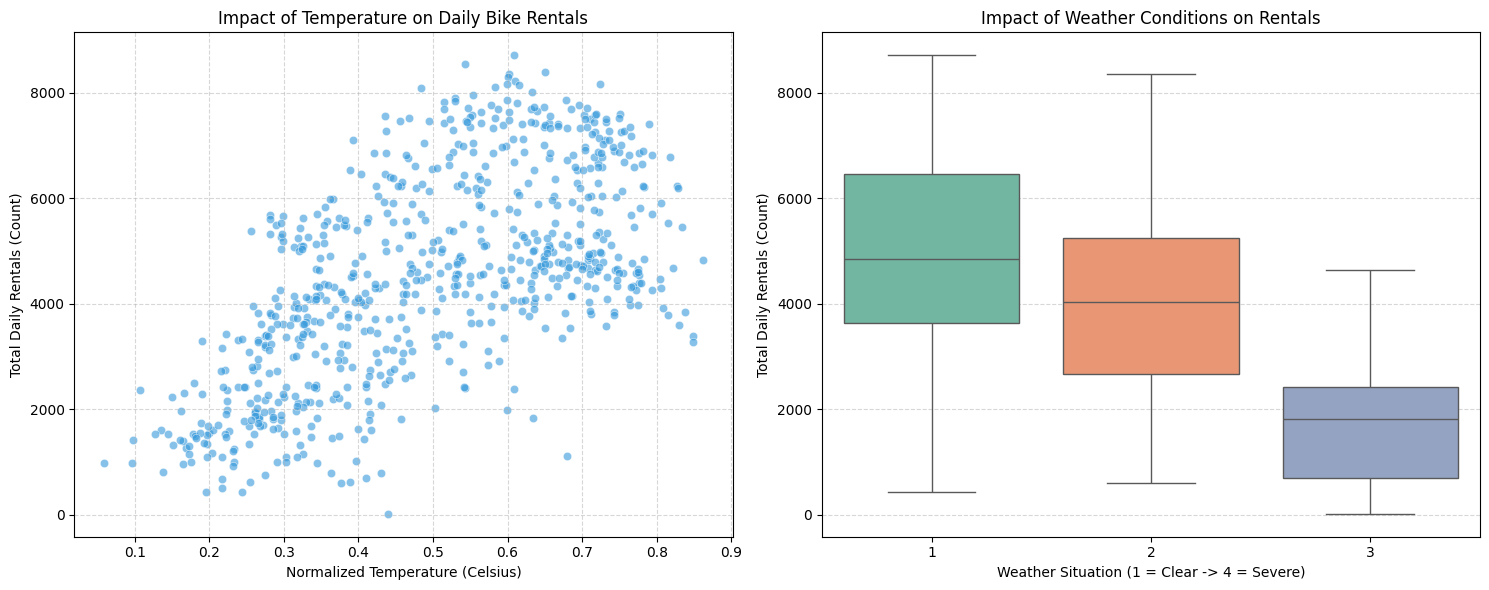

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_bikes = pd.read_csv('../data/bike.csv')

# Create a figure with two subplots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --- Plot 1: Scatter Plot (Temperature vs. Rentals) ---
sns.scatterplot(x='temp', y='cnt', data=df_bikes, ax=axes[0], alpha=0.6, color='#3498db')

# Mandatory Guidelines: Labels and Units
axes[0].set_title('Impact of Temperature on Daily Bike Rentals')
axes[0].set_xlabel('Normalized Temperature (Celsius)')
axes[0].set_ylabel('Total Daily Rentals (Count)')
axes[0].grid(True, linestyle='--', alpha=0.5)

# --- Plot 2: Box Plot (Weather Situation vs. Rentals) ---
# Weather map: 1=Clear, 2=Mist/Cloudy, 3=Light Snow/Rain, 4=Heavy Rain/Snow
sns.boxplot(x='weathersit', y='cnt', data=df_bikes, ax=axes[1], palette='Set2', hue='weathersit', legend=False)

# Mandatory Guidelines: Labels and Units
axes[1].set_title('Impact of Weather Conditions on Rentals')
axes[1].set_xlabel('Weather Situation (1 = Clear -> 4 = Severe)')
axes[1].set_ylabel('Total Daily Rentals (Count)')
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### EDA Conclusions: Environmental Impact on Demand

**The Analysis:** To ensure our target variable (`cnt`) behaves predictably, I visualized its relationship with two distinct environmental features: a continuous variable (Temperature) and a categorical variable (Weather Situation).

**The Findings:**
1. **Temperature (Scatter Plot):** There is a clear positive correlation. As the normalized temperature increases, the daily volume of bike rentals steadily rises, peaking in warmer conditions before naturally tapering off at extreme heat.
2. **Weather Situation (Box Plot):** The rental volume drops drastically as weather worsens. Clear days (Category 1) yield the highest median rentals, while light snow or rain (Category 3) severely depresses demand. 

**Modeling Implications:** This analysis mathematically confirms our real-world intuition: bike-sharing demand is highly elastic and dictated by meteorological factors. Because these features demonstrate a strong, measurable relationship with the target variable, a Regression model will be highly effective at learning these patterns to predict future rental volume.

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# 1. Prevent Data Leakage and Drop Useless Columns
# We drop 'dteday' (we already have month/year columns)
# We drop 'casual' and 'registered' because they add up to exactly our target 'cnt'
X = df_bikes.drop(['cnt', 'casual', 'registered', 'dteday'], axis=1)
y = df_bikes['cnt']

# 2. One-Hot Encode Categorical Variables
# This turns categories like "Season 1, 2, 3" into separate True/False columns
categorical_cols = ['season', 'weathersit', 'mnth', 'weekday']
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# 3. Train/Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

# Helper function to print results cleanly
def evaluate_model(model, name):
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    mae = mean_absolute_error(y_test, predictions)
    r2 = r2_score(y_test, predictions)
    print(f"--- {name} ---")
    print(f"Mean Absolute Error (MAE): {mae:.2f} bikes")
    print(f"R-squared Score (R2):      {r2:.4f}\n")

# 4. Train and Evaluate Model 1: Basic Linear Regression
lr_model = LinearRegression()
evaluate_model(lr_model, "Model 1: Linear Regression")

# 5. Train and Evaluate Model 2: Advanced Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
evaluate_model(rf_model, "Model 2: Random Forest Regressor")

--- Model 1: Linear Regression ---
Mean Absolute Error (MAE): 581.18 bikes
R-squared Score (R2):      0.8436

--- Model 2: Random Forest Regressor ---
Mean Absolute Error (MAE): 452.67 bikes
R-squared Score (R2):      0.8762



### 2.2 Conclusion: Estimator Comparison

To predict our continuous target variable (`cnt`), I compared a standard parametric model (Linear Regression) against a complex, non-parametric ensemble model (Random Forest Regressor). Prior to training, it was strictly necessary to drop the `casual` and `registered` features to prevent data leakage, and apply one-hot encoding to our categorical features.

**The Results:**
* **Linear Regression:** Achieved an $R^2$ score of **0.8436** with a Mean Absolute Error (MAE) of **581.18 bikes**. Linear regression attempts to draw a straight line through the data, which struggles to capture complex, non-linear realities (e.g., rentals drop sharply when it snows, rather than following a gentle slope).
* **Random Forest Regressor:** Significantly outperformed the baseline model, achieving an $R^2$ of **0.8762** and dropping the MAE to **452.67 bikes**. By utilizing a forest of decision trees, the model easily captured non-linear relationships and complex interactions between the weather and seasonal categories, reducing the daily prediction error by nearly 130 bicycles.

**Final Verdict:** For predicting highly elastic, weather-dependent transportation demand, complex ensemble models like Random Forests are required to achieve the accuracy needed for real-world logistical planning.